## 1. Data Preprocessing and Target Variable Preparation

In [1]:
# Cell 1: Import required libraries and load the Excel dataset

import pandas as pd
import numpy as np

# For visualisation later
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# header=2 is used because the actual column names start from the 3rd row in the Excel file
file_path = "Dataset for People for their Blood Glucose Level with their Superficial body feature readings..xlsx"

df = pd.read_excel(file_path, header=2)

# Display first few rows
print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (16969, 10)


,Age,Blood Glucose Level(BGL),Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9,79,73,118,98,98.300707,99,0,0,N
1,9,80,73,119,102,98.300707,94,1,0,N
2,9,70,76,110,81,98.300707,98,1,0,N
3,9,70,78,115,96,98.300707,96,1,0,N
4,66,100,96,144,92,97.807052,98,0,0,N


In [2]:
# Cell 2: Clean column names for easier coding

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_")
)

# Rename columns clearly
df = df.rename(columns={
    "blood_glucose_levelbgl": "blood_glucose_level",
    "diastolic_blood_pressure": "diastolic_blood_pressure",
    "systolic_blood_pressure": "systolic_blood_pressure",
    "heart_rate": "heart_rate",
    "body_temperature": "body_temperature",
    "spo2": "spo2",
    "sweating__y_n": "sweating_y_n",
    "shivering_y_n": "shivering_y_n",
    "diabetic_nondiabetic_d_n": "diabetic_status"
})

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['age', 'blood_glucose_level', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status']


In [3]:
# Cell 3: Check dataset structure, missing values, and duplicate records

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Dataset shape: (16969, 10)

Data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object

Missing values in each column:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64

Number of duplicate rows:
257


In [4]:
# Cell 4: Remove duplicate rows and handle missing values

# Remove exact duplicate rows
df = df.drop_duplicates()

# Drop rows with missing values
# This is suitable here because the dataset has important medical/sensor readings
df = df.dropna()

print("Shape after removing duplicates and missing values:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after removing duplicates and missing values: (16712, 10)

Remaining missing values:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64


In [5]:
# Cell 5: Convert numerical columns to proper numeric format

numeric_columns = [
    "age",
    "blood_glucose_level",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "heart_rate",
    "body_temperature",
    "spo2"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert sweating and shivering into integer format
df["sweating_y_n"] = df["sweating_y_n"].astype(int)
df["shivering_y_n"] = df["shivering_y_n"].astype(int)

print("Updated data types:")
print(df.dtypes)

Updated data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object


In [6]:
# Cell 6: Create the target column for classification

# Target definition:
# 1 = Hypoglycemia
# 0 = Normal / Not hypoglycemia

df["hypoglycemia_status"] = np.where(df["blood_glucose_level"] < 70, 1, 0)

# Keep target column at the end
target_col = df.pop("hypoglycemia_status")
df["hypoglycemia_status"] = target_col

print("Target column created successfully")
print(df["hypoglycemia_status"].value_counts())

print("\nTarget distribution percentage:")
print(df["hypoglycemia_status"].value_counts(normalize=True) * 100)

Target column created successfully
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64

Target distribution percentage:
hypoglycemia_status
0    69.201771
1    30.798229
Name: proportion, dtype: float64


In [7]:
# Cell 7: Encode diabetic_status column

# D = Diabetic
# N = Non-diabetic

df["diabetic_status"] = df["diabetic_status"].astype(str).str.strip().str.upper()

df["diabetic_status"] = df["diabetic_status"].map({
    "D": 1,
    "N": 0
})

print("Diabetic status encoded:")
print(df["diabetic_status"].value_counts())

print("\nDataset after encoding:")
display(df.head())

Diabetic status encoded:
diabetic_status
1    16384
0      328
Name: count, dtype: int64

Dataset after encoding:


,age,blood_glucose_level,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,79,73,118,98,98.300707,99,0,0,0,0
1,9,80,73,119,102,98.300707,94,1,0,0,0
2,9,70,76,110,81,98.300707,98,1,0,0,0
3,9,70,78,115,96,98.300707,96,1,0,0,0
4,66,100,96,144,92,97.807052,98,0,0,0,0


In [8]:
# Cell 8: Prepare final cleaned dataset for machine learning

# IMPORTANT:
# blood_glucose_level is used to create the target.
# Therefore, it should be removed from input features to avoid data leakage.

model_df = df.drop(columns=["blood_glucose_level"])

# Separate input features and target column
X = model_df.drop(columns=["hypoglycemia_status"])
y = model_df["hypoglycemia_status"]

print("Final cleaned dataset shape:", model_df.shape)
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFinal columns used for modelling:")
print(model_df.columns.tolist())

display(model_df.head())

Final cleaned dataset shape: (16712, 10)
Input feature shape: (16712, 9)
Target shape: (16712,)

Final columns used for modelling:
['age', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status', 'hypoglycemia_status']


,age,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,73,118,98,98.300707,99,0,0,0,0
1,9,73,119,102,98.300707,94,1,0,0,0
2,9,76,110,81,98.300707,98,1,0,0,0
3,9,78,115,96,98.300707,96,1,0,0,0
4,66,96,144,92,97.807052,98,0,0,0,0


## 2. Exploratory Data Analysis and Feature Relationship Insights

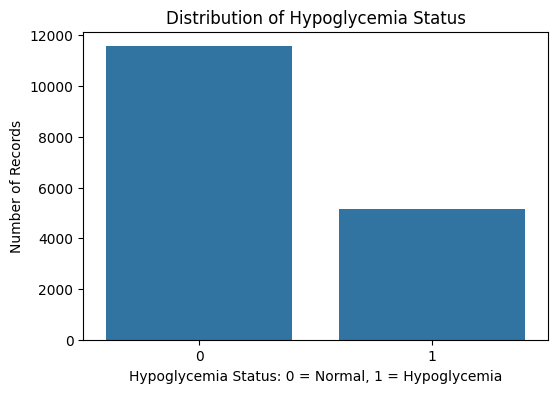

hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64


In [9]:
# EDA Plot 1: Distribution of hypoglycemia target classes

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="hypoglycemia_status"
)

plt.title("Distribution of Hypoglycemia Status")
plt.xlabel("Hypoglycemia Status: 0 = Normal, 1 = Hypoglycemia")
plt.ylabel("Number of Records")

plt.show()

print(df["hypoglycemia_status"].value_counts())

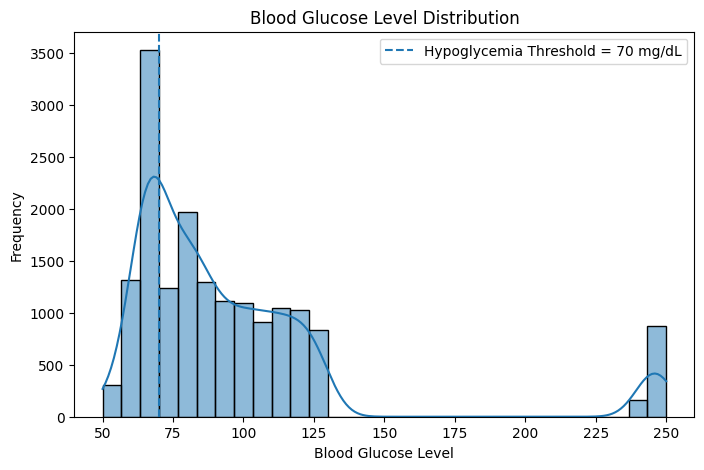

In [10]:
# EDA Plot 2: Distribution of blood glucose level

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="blood_glucose_level",
    bins=30,
    kde=True
)

# Threshold line for hypoglycemia
plt.axvline(70, linestyle="--", label="Hypoglycemia Threshold = 70 mg/dL")

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.legend()

plt.show()

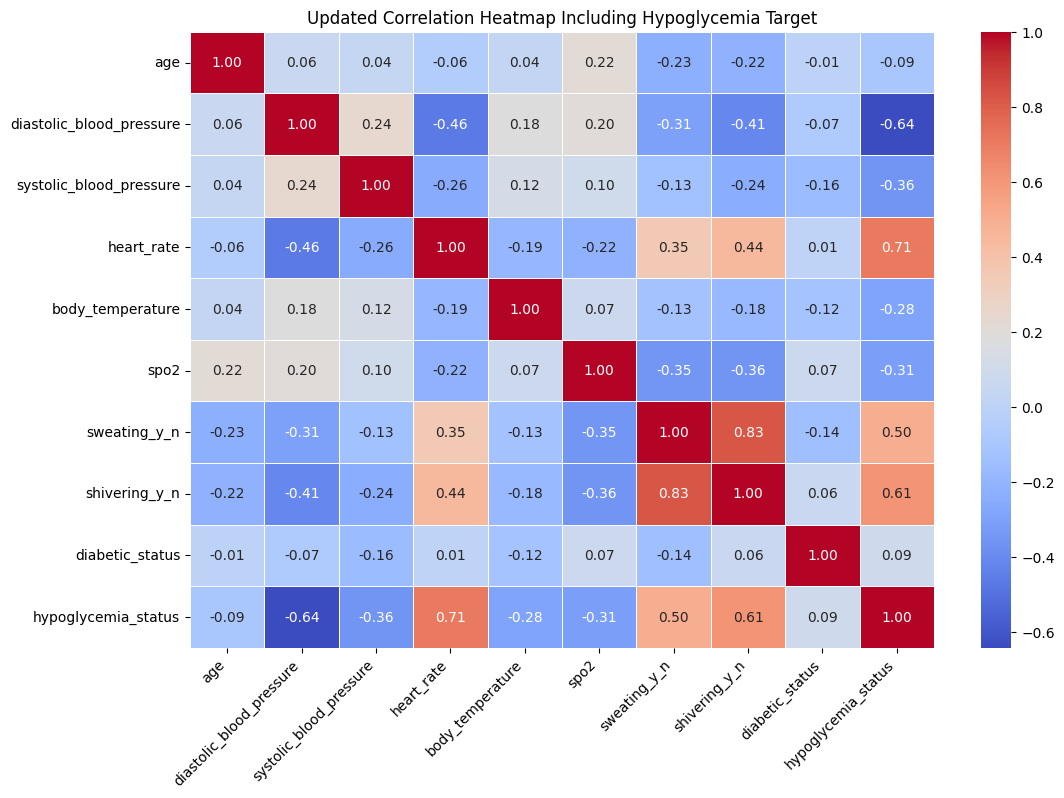

In [11]:
# EDA Plot 3: Correlation heatmap including hypoglycemia target

# Blood glucose level is removed from this heatmap because it directly defines the target.
# This avoids showing an artificial direct relationship.

heatmap_df = df.drop(columns=["blood_glucose_level"])

corr_matrix = heatmap_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Updated Correlation Heatmap Including Hypoglycemia Target")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

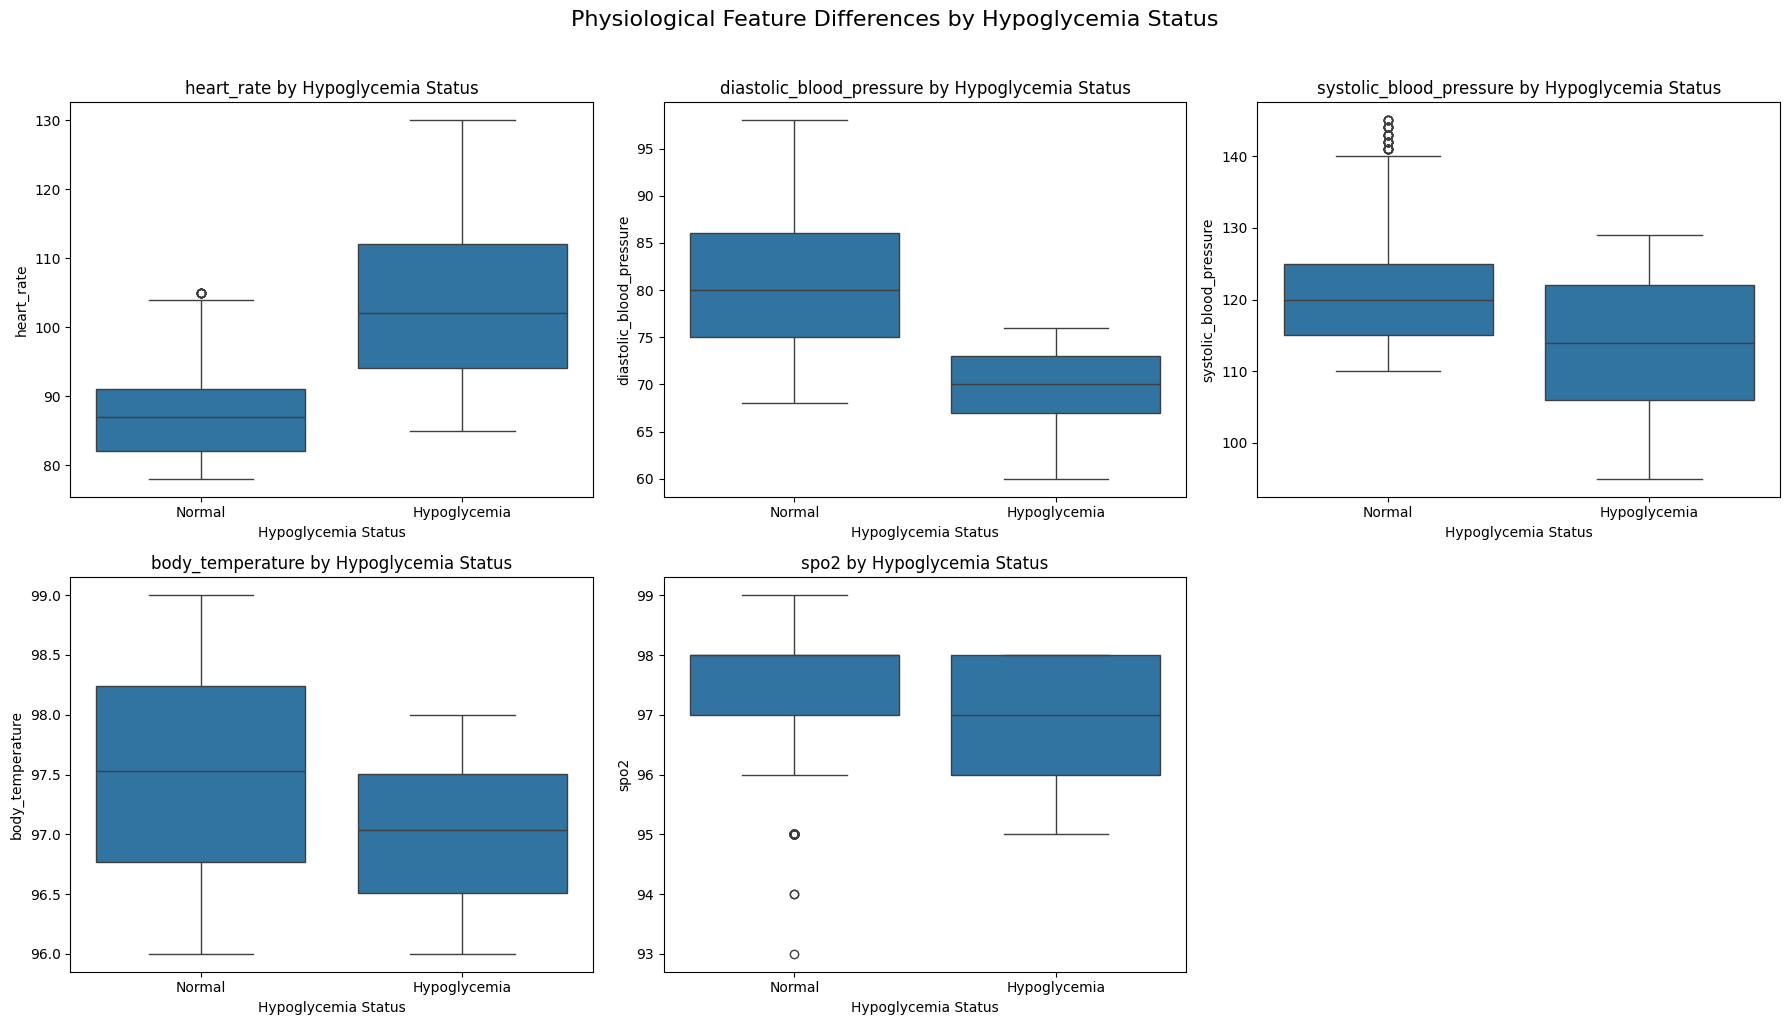

In [12]:
# EDA Plot 4: Physiological feature differences by hypoglycemia status
# This version creates separate boxplots so that all features are clearly visible.
# It avoids the problem of small-range features like body_temperature and spo2 being compressed.

selected_features = [
    "heart_rate",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "body_temperature",
    "spo2"
]

# Create a copy for plotting
plot_df = df.copy()

# Convert target values into readable labels
plot_df["hypoglycemia_label"] = plot_df["hypoglycemia_status"].map({
    0: "Normal",
    1: "Hypoglycemia"
})

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each physiological feature separately
for i, feature in enumerate(selected_features):
    sns.boxplot(
        data=plot_df,
        x="hypoglycemia_label",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Hypoglycemia Status", fontsize=12)
    axes[i].set_xlabel("Hypoglycemia Status")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=0)

# Remove the empty 6th subplot because only 5 features are used
fig.delaxes(axes[-1])

# Main title
fig.suptitle(
    "Physiological Feature Differences by Hypoglycemia Status",
    fontsize=16,
    y=1.02
)

# Adjust layout so all plots, titles, and labels are visible
plt.tight_layout()

plt.show()

### FEATURE SELECTION AND TARGET SEPARATION

In [24]:
# =========================================================
# SECTION 4: FEATURE SELECTION AND TARGET SEPARATION
# =========================================================

# Target column
target_column = "hypoglycemia_status"

# Use final cleaned dataset
final_df = model_df.copy()

# Safety check:
# blood_glucose_level should not be used as input feature
# because it was used to create hypoglycemia_status.
if "blood_glucose_level" in final_df.columns:
    final_df = final_df.drop(columns=["blood_glucose_level"])

# Separate input features and target
X = final_df.drop(columns=[target_column])
y = final_df[target_column]

print("Feature and target separation completed")
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features used:")
print(X.columns.tolist())

print("\nOriginal target distribution:")
print(y.value_counts())

Feature and target separation completed
Input feature shape: (16712, 9)
Target shape: (16712,)

Input features used:
['age', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status']

Original target distribution:
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64


# Applying StandardScaler before SMOTE

In [25]:
# =========================================================
# SECTION 5: STANDARD SCALING
# =========================================================

from sklearn.preprocessing import StandardScaler

# StandardScaler is used to bring all features to a similar scale.
# This is useful for SMOTE and ANN because both are sensitive to feature distance/scale.

scaler = StandardScaler()

# In this version, scaling is applied before SMOTE and before train-test split,
# as per the new experiment requirement.
X_scaled = scaler.fit_transform(X)

print("StandardScaler applied successfully")
print("Scaled feature shape:", X_scaled.shape)

StandardScaler applied successfully
Scaled feature shape: (16712, 9)


# Apply SMOTE before train-test split

In [26]:
# =========================================================
# SECTION 6: APPLY SMOTE BEFORE TRAIN-TEST SPLIT
# =========================================================

from imblearn.over_sampling import SMOTE

# SMOTE is used to balance the target classes by creating synthetic minority-class records.
# Here SMOTE is applied before train-test split as requested for the new version.

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_scaled, y)

print("SMOTE applied before train-test split")

print("\nTarget distribution before SMOTE:")
print(y.value_counts())

print("\nTarget distribution after SMOTE:")
print(y_smote.value_counts())

print("\nX_smote shape:", X_smote.shape)
print("y_smote shape:", y_smote.shape)

SMOTE applied before train-test split

Target distribution before SMOTE:
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64

Target distribution after SMOTE:
hypoglycemia_status
0    11565
1    11565
Name: count, dtype: int64

X_smote shape: (23130, 9)
y_smote shape: (23130,)


In [27]:
# =========================================================
# SECTION 7: TRAIN-TEST SPLIT AFTER SMOTE
# =========================================================

from sklearn.model_selection import train_test_split

# The balanced SMOTE dataset is now split into training and testing sets.
# stratify=y_smote keeps equal class distribution in train and test data.

X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.20,
    random_state=42,
    stratify=y_smote
)

print("Train-test split completed after SMOTE")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Train-test split completed after SMOTE
X_train shape: (18504, 9)
X_test shape: (4626, 9)
y_train shape: (18504,)
y_test shape: (4626,)

Training target distribution:
hypoglycemia_status
0    9252
1    9252
Name: count, dtype: int64

Testing target distribution:
hypoglycemia_status
1    2313
0    2313
Name: count, dtype: int64


# Random Forest base model with metrics, confusion matrix and ROC curve

Random Forest Base Model Results
--------------------------------
Accuracy : 0.9825
Precision: 0.9878
Recall   : 0.9771
F1-score : 0.9824
ROC-AUC  : 0.999

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.99      0.98      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



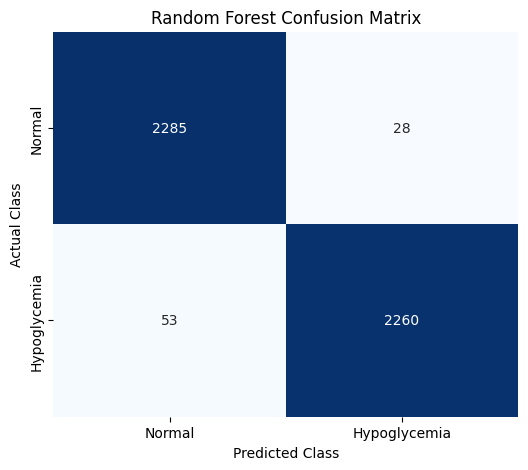

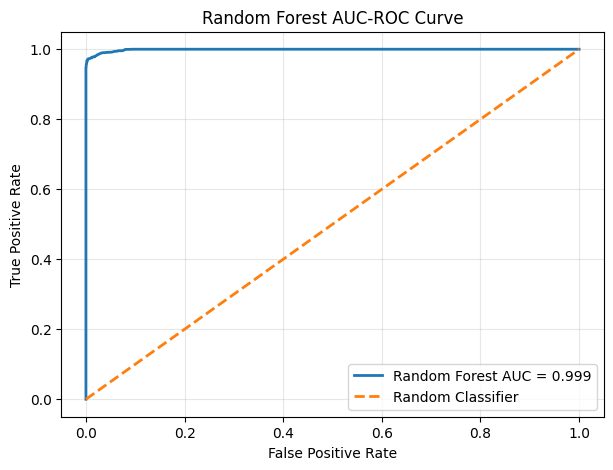

In [28]:
# =========================================================
# MODEL 1: RANDOM FOREST BASE MODEL
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# Train Random Forest model
rf_model.fit(X_train, y_train)

# Predict class labels
rf_pred = rf_model.predict(X_test)

# Predict probability for class 1: Hypoglycemia
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest Base Model Results")
print("--------------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_proba)
rf_auc_value = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest AUC = {rf_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Random Forest AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Random Forest hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

Best Random Forest CV ROC-AUC:
0.9988

Tuned Random Forest Results
---------------------------
Accuracy : 0.9825
Precision: 0.9916
Recall   : 0.9732
F1-score : 0.9823
ROC-AUC  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      2313
Hypoglycemia       0.99      0.97      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



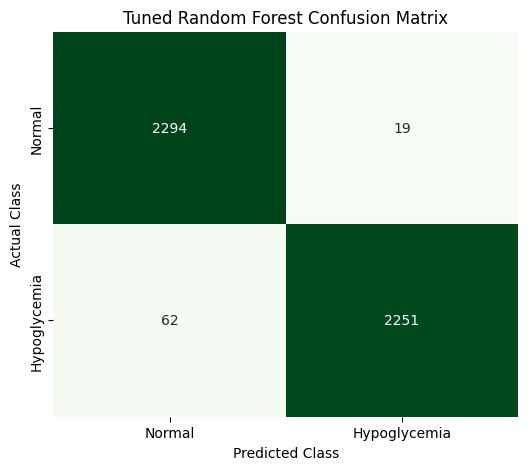

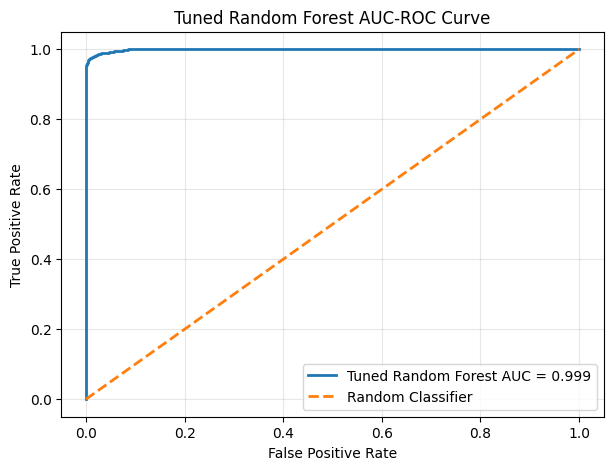

In [29]:
# =========================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================

# Base model for tuning
rf_base = RandomForestClassifier(
    random_state=42
)

# Parameter search space
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
rf_random_search.fit(X_train, y_train)

# Best tuned Random Forest model
best_rf_model = rf_random_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(round(rf_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned Random Forest
# ---------------------------------------------------------

rf_tuned_pred = best_rf_model.predict(X_test)
rf_tuned_proba = best_rf_model.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_proba)

print("\nTuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(rf_tuned_accuracy, 4))
print("Precision:", round(rf_tuned_precision, 4))
print("Recall   :", round(rf_tuned_recall, 4))
print("F1-score :", round(rf_tuned_f1, 4))
print("ROC-AUC  :", round(rf_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

rf_tuned_cm = confusion_matrix(y_test, rf_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

rf_tuned_fpr, rf_tuned_tpr, rf_tuned_thresholds = roc_curve(y_test, rf_tuned_proba)
rf_tuned_auc_value = auc(rf_tuned_fpr, rf_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_tuned_fpr,
    rf_tuned_tpr,
    linewidth=2,
    label=f"Tuned Random Forest AUC = {rf_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned Random Forest AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## XGBoost base model with metrics, confusion matrix and ROC curve

XGBoost Base Model Results
--------------------------
Accuracy : 0.9784
Precision: 1.0
Recall   : 0.9568
F1-score : 0.9779
ROC-AUC  : 0.9988

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      2313
Hypoglycemia       1.00      0.96      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



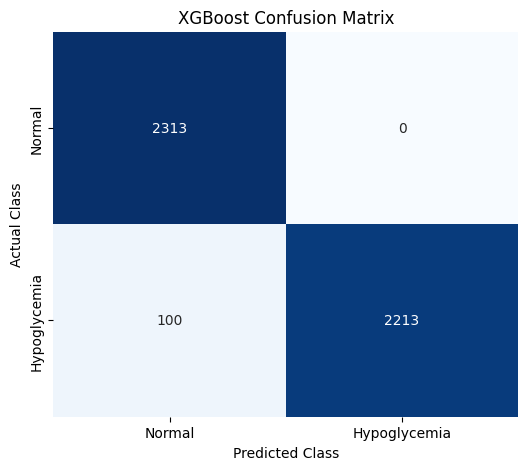

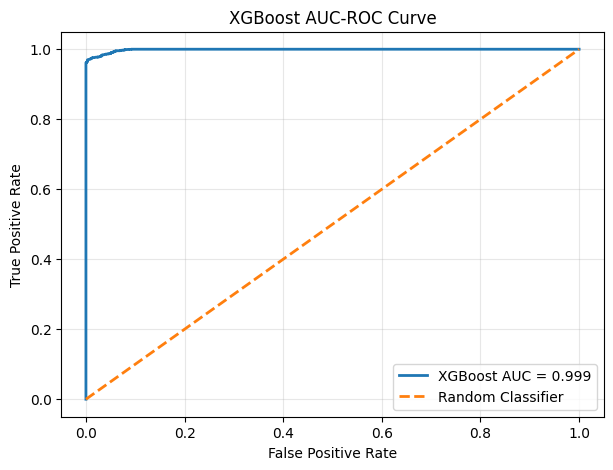

In [30]:
# =========================================================
# MODEL 2: XGBOOST BASE MODEL
# =========================================================

from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train XGBoost model
xgb_model.fit(X_train, y_train)

# Predict class labels
xgb_pred = xgb_model.predict(X_test)

# Predict probability for class 1: Hypoglycemia
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("XGBoost Base Model Results")
print("--------------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, xgb_proba)
xgb_auc_value = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f"XGBoost AUC = {xgb_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("XGBoost AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# XGBoost hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best XGBoost CV ROC-AUC:
0.9988

Tuned XGBoost Results
---------------------
Accuracy : 0.984
Precision: 0.9899
Recall   : 0.978
F1-score : 0.9839
ROC-AUC  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.99      0.98      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



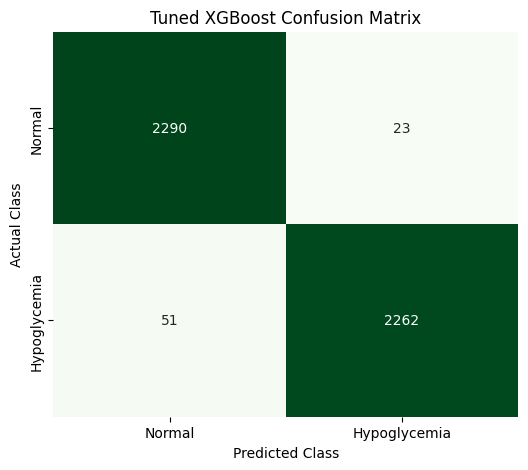

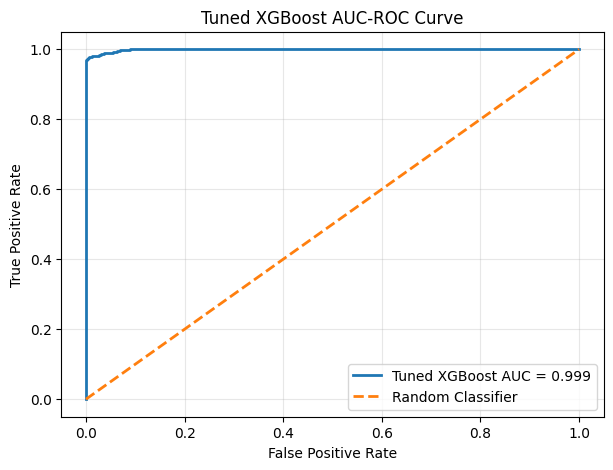

In [31]:
# =========================================================
# XGBOOST HYPERPARAMETER TUNING
# =========================================================

# Base model for tuning
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameter search space
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2]
}

# RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
xgb_random_search.fit(X_train, y_train)

# Best tuned XGBoost model
best_xgb_model = xgb_random_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nBest XGBoost CV ROC-AUC:")
print(round(xgb_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned XGBoost
# ---------------------------------------------------------

xgb_tuned_pred = best_xgb_model.predict(X_test)
xgb_tuned_proba = best_xgb_model.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)
xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_proba)

print("\nTuned XGBoost Results")
print("---------------------")
print("Accuracy :", round(xgb_tuned_accuracy, 4))
print("Precision:", round(xgb_tuned_precision, 4))
print("Recall   :", round(xgb_tuned_recall, 4))
print("F1-score :", round(xgb_tuned_f1, 4))
print("ROC-AUC  :", round(xgb_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

xgb_tuned_cm = confusion_matrix(y_test, xgb_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

xgb_tuned_fpr, xgb_tuned_tpr, xgb_tuned_thresholds = roc_curve(y_test, xgb_tuned_proba)
xgb_tuned_auc_value = auc(xgb_tuned_fpr, xgb_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_tuned_fpr,
    xgb_tuned_tpr,
    linewidth=2,
    label=f"Tuned XGBoost AUC = {xgb_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned XGBoost AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ANN base model with metrics, confusion matrix and ROC curve

ANN Base Model Results
----------------------
Accuracy : 0.9725
Precision: 0.9711
Recall   : 0.9741
F1-score : 0.9726
ROC-AUC  : 0.9981

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      2313
Hypoglycemia       0.97      0.97      0.97      2313

    accuracy                           0.97      4626
   macro avg       0.97      0.97      0.97      4626
weighted avg       0.97      0.97      0.97      4626



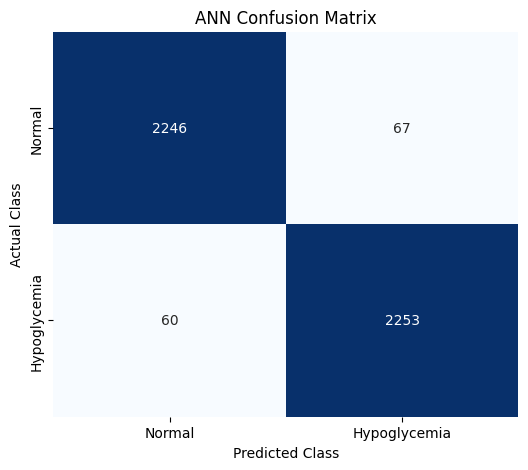

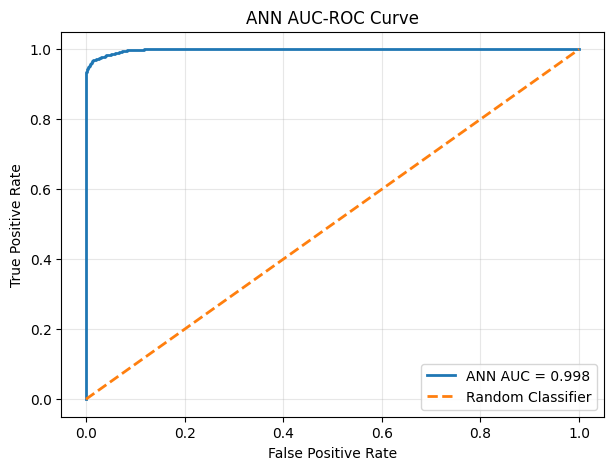

In [32]:
# =========================================================
# MODEL 3: ANN BASE MODEL
# =========================================================

from sklearn.neural_network import MLPClassifier

# Create ANN model
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train ANN model
ann_model.fit(X_train, y_train)

# Predict class labels
ann_pred = ann_model.predict(X_test)

# Predict probability for class 1: Hypoglycemia
ann_proba = ann_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)
ann_auc = roc_auc_score(y_test, ann_proba)

print("ANN Base Model Results")
print("----------------------")
print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1-score :", round(ann_f1, 4))
print("ROC-AUC  :", round(ann_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    ann_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

ann_cm = confusion_matrix(y_test, ann_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

ann_fpr, ann_tpr, ann_thresholds = roc_curve(y_test, ann_proba)
ann_auc_value = auc(ann_fpr, ann_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    ann_fpr,
    ann_tpr,
    linewidth=2,
    label=f"ANN AUC = {ann_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("ANN AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ANN hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best ANN Parameters:
{'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'activation': 'relu'}

Best ANN CV ROC-AUC:
0.9974

Tuned ANN Results
-----------------
Accuracy : 0.9682
Precision: 0.9721
Recall   : 0.9641
F1-score : 0.9681
ROC-AUC  : 0.9974

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97      2313
Hypoglycemia       0.97      0.96      0.97      2313

    accuracy                           0.97      4626
   macro avg       0.97      0.97      0.97      4626
weighted avg       0.97      0.97      0.97      4626



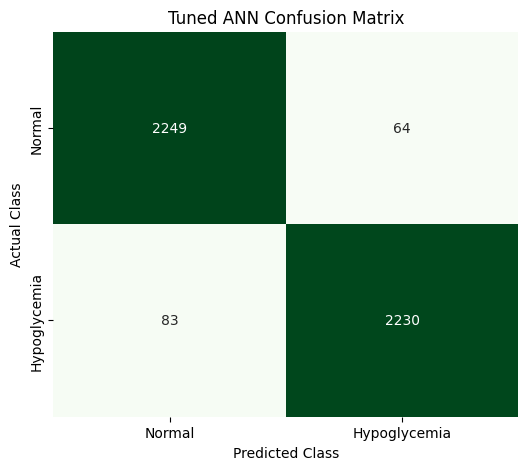

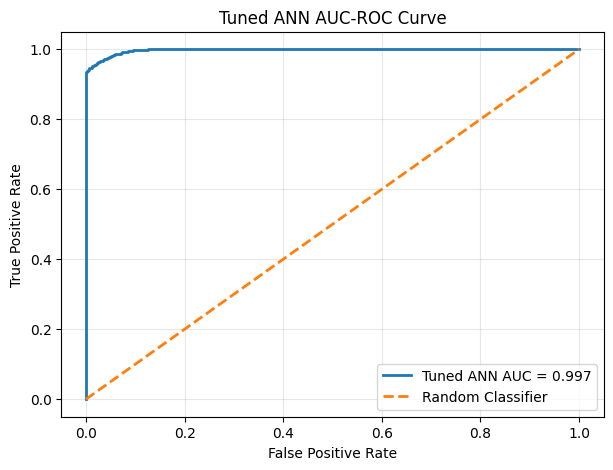

In [33]:
# =========================================================
# ANN HYPERPARAMETER TUNING
# =========================================================

# Base model for tuning
ann_base = MLPClassifier(
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# Parameter search space
ann_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.005, 0.01]
}

# RandomizedSearchCV
ann_random_search = RandomizedSearchCV(
    estimator=ann_base,
    param_distributions=ann_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
ann_random_search.fit(X_train, y_train)

# Best tuned ANN model
best_ann_model = ann_random_search.best_estimator_

print("Best ANN Parameters:")
print(ann_random_search.best_params_)

print("\nBest ANN CV ROC-AUC:")
print(round(ann_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned ANN
# ---------------------------------------------------------

ann_tuned_pred = best_ann_model.predict(X_test)
ann_tuned_proba = best_ann_model.predict_proba(X_test)[:, 1]

ann_tuned_accuracy = accuracy_score(y_test, ann_tuned_pred)
ann_tuned_precision = precision_score(y_test, ann_tuned_pred)
ann_tuned_recall = recall_score(y_test, ann_tuned_pred)
ann_tuned_f1 = f1_score(y_test, ann_tuned_pred)
ann_tuned_auc = roc_auc_score(y_test, ann_tuned_proba)

print("\nTuned ANN Results")
print("-----------------")
print("Accuracy :", round(ann_tuned_accuracy, 4))
print("Precision:", round(ann_tuned_precision, 4))
print("Recall   :", round(ann_tuned_recall, 4))
print("F1-score :", round(ann_tuned_f1, 4))
print("ROC-AUC  :", round(ann_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    ann_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

ann_tuned_cm = confusion_matrix(y_test, ann_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    ann_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned ANN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

ann_tuned_fpr, ann_tuned_tpr, ann_tuned_thresholds = roc_curve(y_test, ann_tuned_proba)
ann_tuned_auc_value = auc(ann_tuned_fpr, ann_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    ann_tuned_fpr,
    ann_tuned_tpr,
    linewidth=2,
    label=f"Tuned ANN AUC = {ann_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned ANN AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# =========================================================
# FINAL COMPARISON: THREE MODELS BEFORE AND AFTER SMOTE
# =========================================================

import pandas as pd

# Create final comparison table
final_before_after_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest",
        "XGBoost",
        "XGBoost",
        "ANN",
        "ANN"
    ],

    "SMOTE Status": [
        "Before SMOTE",
        "After SMOTE",
        "Before SMOTE",
        "After SMOTE",
        "Before SMOTE",
        "After SMOTE"
    ],

    "Accuracy": [
        rf_accuracy_before,
        rf_accuracy,
        xgb_accuracy_before,
        xgb_accuracy,
        ann_accuracy_before,
        ann_accuracy
    ],

    "Precision": [
        rf_precision_before,
        rf_precision,
        xgb_precision_before,
        xgb_precision,
        ann_precision_before,
        ann_precision
    ],

    "Recall": [
        rf_recall_before,
        rf_recall,
        xgb_recall_before,
        xgb_recall,
        ann_recall_before,
        ann_recall
    ],

    "F1-score": [
        rf_f1_before,
        rf_f1,
        xgb_f1_before,
        xgb_f1,
        ann_f1_before,
        ann_f1
    ],

    "ROC-AUC": [
        rf_auc_before,
        rf_auc,
        xgb_auc_before,
        xgb_auc,
        ann_auc_before,
        ann_auc
    ]
})

# Round values for clean display
final_before_after_results = final_before_after_results.round(4)

print("Final Model Results Before and After SMOTE")
print("------------------------------------------")

display(final_before_after_results)

Final Model Results Before and After SMOTE
------------------------------------------


,Model,SMOTE Status,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,Before SMOTE,0.9797,0.9898,0.9437,0.9662,0.9972
1,Random Forest,After SMOTE,0.9825,0.9878,0.9771,0.9824,0.9990
2,XGBoost,Before SMOTE,0.9815,1.0000,0.9398,0.9690,0.9974
3,XGBoost,After SMOTE,0.9784,1.0000,0.9568,0.9779,0.9988
4,ANN,Before SMOTE,0.9776,0.9799,0.9466,0.9630,0.9970
5,ANN,After SMOTE,0.9725,0.9711,0.9741,0.9726,0.9981
